<a href="https://colab.research.google.com/github/ykitaguchi77/AI-Article-Writer/blob/main/Blepharospasm_sensory_trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Blepharospasm_sensory_trick**

In [1]:
# prompt: gdriveをマウント

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



=== Age Descriptive Statistics ===
                  count   mean  Median    std   IQR
Condition                                          
Blepharospasm      32.0  68.03    68.5  10.92  14.0
Hemifacial spasm   17.0  76.88    80.0  10.10   9.0

=== Sex Distribution (counts & %) ===
Sex_label         Female  Male  Female (%)  Male (%)
Condition                                           
Blepharospasm         23     9        71.9      28.1
Hemifacial spasm      11     6        64.7      35.3

=== Group Comparison Tests ===
Age  (Mann–Whitney U) : U = 422.0, p = 0.0017
Sex  (Chi-square)    : χ² = 0.04, p = 0.8472


/tmp/ipython-input-3085361509.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=conditions_order, showfliers=True)


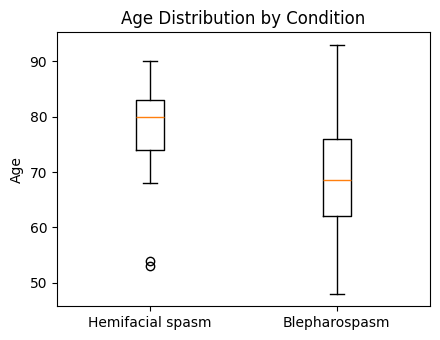

In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import re

# ------------------------------
# データ読み込み
# ------------------------------
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')

# ------------------------------
# 対象抽出（Type 0 と 1）
# ------------------------------
df_filtered = (
    df[['Type', 'Age', 'Sex']]
      .dropna(subset=['Type', 'Age', 'Sex'])
      .query("Type in [0, 1]")
      .copy()
)
condition_map = {0: 'Hemifacial spasm', 1: 'Blepharospasm'}
sex_map       = {0: 'Male', 1: 'Female'}
df_filtered['Condition'] = df_filtered['Type'].map(condition_map)
df_filtered['Sex_label'] = df_filtered['Sex'].map(sex_map)

# ==========================================================
# Ⅰ. 生の統計値 ------------------------------------------------
# ==========================================================
# 1) 年齢の記述統計（群別）
age_desc = (
    df_filtered.groupby('Condition')['Age']
               .describe()
               .rename(columns={'50%':'Median'})
               .round(2)
)

# 2) 年齢 IQR を追加
age_desc['IQR'] = (age_desc['75%'] - age_desc['25%']).round(2)

# 3) 性別クロス集計（カウントと％）
sex_counts = pd.crosstab(df_filtered['Condition'], df_filtered['Sex_label'])
sex_pct    = (sex_counts.div(sex_counts.sum(axis=1), axis=0)*100
              ).round(1).add_suffix(' (%)')
sex_table  = pd.concat([sex_counts, sex_pct], axis=1)

# 4) 群間検定
#    年齢：Mann-Whitney U
u_stat, p_age = stats.mannwhitneyu(
    df_filtered.loc[df_filtered['Condition']=='Hemifacial spasm','Age'],
    df_filtered.loc[df_filtered['Condition']=='Blepharospasm','Age'],
    alternative='two-sided'
)
#    性別：χ²
chi2_stat, chi2_p, _, _ = stats.chi2_contingency(sex_counts)

# ------------------------------
# 文字出力
# ------------------------------
print('\n=== Age Descriptive Statistics ===')
print(age_desc[['count','mean','Median','std','IQR']])

print('\n=== Sex Distribution (counts & %) ===')
print(sex_table)

print('\n=== Group Comparison Tests ===')
print(f'Age  (Mann–Whitney U) : U = {u_stat:.1f}, p = {p_age:.4f}')
print(f'Sex  (Chi-square)    : χ² = {chi2_stat:.2f}, p = {chi2_p:.4f}')

# ==========================================================
# Ⅱ. グラフ（箱ひげ図） --------------------------------------
# ==========================================================
plt.figure(figsize=(4.5,3.5))
conditions_order = ['Hemifacial spasm', 'Blepharospasm']
box_data = [df_filtered.loc[df_filtered['Condition']==c, 'Age']
            for c in conditions_order]
plt.boxplot(box_data, labels=conditions_order, showfliers=True)
plt.ylabel('Age')
plt.title('Age Distribution by Condition')
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import re
import scipy.stats as stats  # 正規性検定用

# --- Load data ---
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')

# --- Pre-processing ---
df.columns = df.columns.str.strip()
bleph = df[df['Type'] == 1].copy()
n_total = len(bleph)

# --- Surgery history flag（★先に作る） ---
def has_surgery(val):
    if pd.isna(val):
        return 'No'
    if isinstance(val, (int, float)) and val == 0:
        return 'No'
    if isinstance(val, str) and re.fullmatch(r'\s*0\s*', val):
        return 'No'
    return 'Yes'

bleph['Surgery_history'] = bleph['History'].apply(has_surgery)

# --- Helper for numeric summaries ---
def summary_series(s):
    d = s.describe()
    return {
        'Count':  int(d['count']),
        'Min':    d['min'],
        'Q1':     d['25%'],
        'Median': d['50%'],
        'Q3':     d['75%'],
        'Max':    d['max'],
        'Mean':   d['mean'],
        'Std':    d['std'],
        'IQR':    d['75%'] - d['25%']
    }

# ================
# 正規性検定 (全体)
# ================
def normality_label(p):
    return "Normal (p≥0.05)" if p >= 0.05 else "Non-normal (p<0.05)"

num_vars_all = ['Age', 'Duration', 'Interval', 'Botox_unit']
norm_rows_total = []

for v in num_vars_all:
    if v not in bleph.columns:
        continue
    s = bleph[v].dropna()
    if len(s) >= 3:  # Shapiro–Wilkはn>=3が必要
        W, p = stats.shapiro(s)
        norm_rows_total.append({
            'Variable': v,
            'N': len(s),
            'W': W,
            'p_value': p,
            'Normality': normality_label(p)
        })

normality_total_df = pd.DataFrame(norm_rows_total)

# =====================================
# 正規性検定 (Surgery_history 別)
# =====================================
norm_rows_hist = []
for v in ['Duration', 'Interval']:
    if v not in bleph.columns:
        continue
    for grp, gdf in bleph.groupby('Surgery_history'):
        s = gdf[v].dropna()
        if len(s) >= 3:
            W, p = stats.shapiro(s)
            norm_rows_hist.append({
                'Variable': v,
                'Surgery_history': grp,
                'N': len(s),
                'W': W,
                'p_value': p,
                'Normality': normality_label(p)
            })

normality_hist_df = pd.DataFrame(norm_rows_hist)

# --- Age summary ---
age_summary_df = pd.DataFrame([summary_series(bleph['Age'])])

# --- Sex distribution ---
sex_map = {0: 'Male', 1: 'Female'}
bleph['Sex_label'] = bleph['Sex'].map(sex_map)
sex_counts = bleph['Sex_label'].value_counts(dropna=False)
sex_pct = (sex_counts / n_total * 100).round(1)
sex_df = pd.DataFrame({'Count': sex_counts, 'Percent': sex_pct})

# --- Numeric variables summary ---
num_vars = ['Duration', 'Interval', 'Botox_unit']
num_summary_rows = []
for v in num_vars:
    if v in bleph.columns:
        num_summary_rows.append({'Variable': v, **summary_series(bleph[v])})
num_summary_df = pd.DataFrame(num_summary_rows)

# --- Categorical variables summary ---
cat_vars = ['Botox_abovebrow', 'Botox_glabellar']
cat_summary_rows = []
for var in cat_vars:
    if var not in bleph.columns:
        continue
    counts = bleph[var].value_counts(dropna=False)
    pct = (counts / n_total * 100).round(1)
    for cat, cnt in counts.items():
        cat_summary_rows.append({
            'Variable': var,
            'Category': cat,
            'Count': cnt,
            'Percent': pct[cat]
        })
cat_summary_df = pd.DataFrame(cat_summary_rows)

# --- Sensory trick presence ---
bleph['Sensory_trick_present'] = (
    (bleph['SensoryTrick_temple'] == 1) |
    (bleph['SensoryTrick_subbrow'] == 1)
).astype(float)
sens_counts = bleph['Sensory_trick_present'].value_counts(dropna=False)
sens_pct = (sens_counts / n_total * 100).round(1)
sens_df = pd.DataFrame({'Count': sens_counts, 'Percent': sens_pct})

# --- Surgery history distribution ---
hist_counts = bleph['Surgery_history'].value_counts(dropna=False)
hist_pct = (hist_counts / n_total * 100).round(1)
hist_df = pd.DataFrame({'Count': hist_counts, 'Percent': hist_pct})

# --- Numeric summaries by surgery history ---
rows = []
for var in ['Duration', 'Interval']:
    if var not in bleph.columns:
        continue
    for grp, gdf in bleph.groupby('Surgery_history'):
        rows.append({'Variable': var, 'Surgery_history': grp, **summary_series(gdf[var])})
summary_by_hist_df = pd.DataFrame(rows)

# --- Display ---
print("=== Normality (Total) ===")
print(normality_total_df, "\n")

print("=== Normality by Surgery History ===")
print(normality_hist_df, "\n")

print("=== Age ===")
print(age_summary_df, "\n")

print("=== Sex ===")
print(sex_df, "\n")

print("=== Numeric ===")
print(num_summary_df, "\n")

print("=== Categorical ===")
print(cat_summary_df, "\n")

print("=== Sensory Trick ===")
print(sens_df, "\n")

print("=== Surgery History ===")
print(hist_df, "\n")

print("=== Summary by Surgery ===")
print(summary_by_hist_df, "\n")


=== Normality (Total) ===
     Variable   N         W       p_value            Normality
0         Age  32  0.957031  2.274145e-01      Normal (p≥0.05)
1    Duration  32  0.875951  1.597510e-03  Non-normal (p<0.05)
2    Interval  32  0.672414  3.448074e-07  Non-normal (p<0.05)
3  Botox_unit  32  0.915657  1.587910e-02  Non-normal (p<0.05) 

=== Normality by Surgery History ===
   Variable Surgery_history   N         W   p_value            Normality
0  Duration              No  20  0.830919  0.002595  Non-normal (p<0.05)
1  Duration             Yes  12  0.946491  0.586382      Normal (p≥0.05)
2  Interval              No  20  0.760246  0.000234  Non-normal (p<0.05)
3  Interval             Yes  12  0.450017  0.000008  Non-normal (p<0.05) 

=== Age ===
   Count   Min    Q1  Median    Q3   Max      Mean        Std   IQR
0     32  48.0  62.0    68.5  76.0  93.0  68.03125  10.923441  14.0 

=== Sex ===
           Count  Percent
Sex_label                
Female        23     71.9
Male         

=== Effect duration (months) descriptive stats ===
                   count      mean      std  min    25%  50%    75%  max   IQR
Effect_duration_M   12.0  1.916667  0.55732  0.5  1.875  2.0  2.125  2.5  0.25 

=== Complaint text frequency ===
           Complaint  Count
0                  0     11
1               ちょうど      2
2      眼は調子良い、口が調子悪い      1
3          効果ないと訴えあり      1
4  効果に不満、食事時につむってしまう      1
5          あまり効いていない      1
6  効果に不満。眉毛が落ちて開きにくい      1
7              効果に不満      1
8                 なし      1 



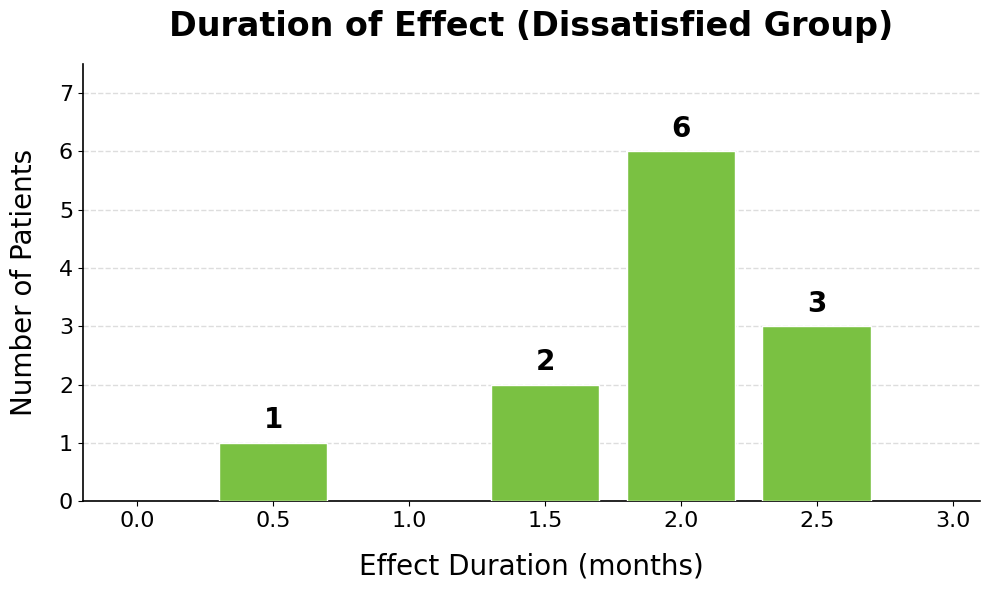

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. データ読み込みと前処理
# ==========================================
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')

# Type 1 (眼瞼痙攣) のみを抽出
bleph = df[df['Type'] == 1].copy()

# ==========================================
# 2. テキスト解析関数の定義
# ==========================================

# --- 関数1: 不満コメントから期間（月数）を抽出 ---
def extract_duration(val):
    if pd.isna(val):
        return None
    # 「数字 + M/m/ヶ月」のパターンを正規表現で検索
    match = re.search(r'(\d+(?:\.\d+)?)\s*[Mm]', str(val))
    if match:
        return float(match.group(1))
    return None

# --- 関数2: 期間以外の不満テキストを抽出 ---
def complaint_or_blank(val):
    if pd.isna(val):
        return None
    # 期間が含まれていれば、それは「期間データ」として扱うためテキストは無視
    if extract_duration(val) is not None:
        return None
    # それ以外のテキストを不満内容として返す
    return str(val).strip()

# ==========================================
# 3. データへの適用と集計
# ==========================================

# 列を作成
bleph['Effect_duration_M'] = bleph['Botox_dissatisfaction'].apply(extract_duration)
bleph['Complaint_text'] = bleph['Botox_dissatisfaction'].apply(complaint_or_blank)

# --- 統計量（期間）の計算 ---
duration_series = bleph['Effect_duration_M'].dropna()
duration_stats = duration_series.describe()
duration_stats_df = pd.DataFrame(duration_stats).transpose()
# 四分位範囲 (IQR) を追加
duration_stats_df['IQR'] = duration_stats_df['75%'] - duration_stats_df['25%']

# --- 不満内容（テキスト）の集計 ---
complaints = bleph['Complaint_text'].dropna()
complaint_counts = complaints.value_counts()
complaint_df = complaint_counts.reset_index()
complaint_df.columns = ['Complaint', 'Count']

# ==========================================
# 4. 結果の表示（コンソール出力）
# ==========================================
print("=== Effect duration (months) descriptive stats ===")
print(duration_stats_df, "\n")

print("=== Complaint text frequency ===")
print(complaint_df, "\n")

# ==========================================
# 5. グラフ描画（自動データ取得・大文字版）
# ==========================================

# 自動集計: 月数ごとの人数をカウントし、月数の昇順にソート
duration_counts = bleph['Effect_duration_M'].value_counts().sort_index()
durations = duration_counts.index.tolist()
counts = duration_counts.values.tolist()

# グラフ設定
plt.figure(figsize=(10, 6))

# 棒グラフ描画
bars = plt.bar(durations, counts, width=0.4, color="#7AC142", edgecolor='white', zorder=3)

# --- データラベル（棒の上の数字） ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=20, fontweight='bold'
    )

# --- タイトルと軸ラベル ---
plt.title("Duration of Effect (Dissatisfied Group)", fontsize=24, weight='bold', pad=20)
plt.xlabel("Effect Duration (months)", fontsize=20, labelpad=15)
plt.ylabel("Number of Patients", fontsize=20, labelpad=15)

# --- 軸の目盛り（数字）の自動調整 ---
# データの最大値を取得
max_duration = max(durations) if durations else 3.0
max_count = max(counts) if counts else 5

# X軸: 0から最大値+0.5まで、0.5刻み
x_ticks = np.arange(0, max_duration + 0.6, 0.5)
plt.xticks(x_ticks, fontsize=16)
plt.xlim(-0.2, max_duration + 0.6) # 左右の余白

# Y軸: 整数のみ表示
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.yticks(fontsize=16)
plt.ylim(0, max_count + 1.5) # 上の余白

# デザイン調整（枠線削除・グリッド）
plt.grid(axis='y', color='#DDDDDD', linestyle='--', linewidth=1, zorder=0)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.show()

In [ ]:
import re
import pandas as pd

# ------- ① データ読み込み -------
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')

# ------- ② 事前処理 -------
bleph = df[df['Type'] == 1].copy()               # Type1 = Blepharospasm
bleph['Botox_dissatisfaction'] = (
    bleph['Botox_dissatisfaction']
    .astype(str)
    .str.strip()
    .replace({'nan': None})                      # NaN 表示を元に戻す
)

# ------- ③ 分類関数 -------
def classify(text: str):
    # 不満なしパターン（0・なし・ちょうど等）
    if text in [None, '', '0', '0.0', '０', 'ちょうど', 'なし']:
        # effect, duration, none
        return 0, 0, 1

    # 期間ワード（「何ヶ月」「持たない」「直前」「切れる」など）
    duration_pat = re.compile(
        r'\d+\s*(ヶ月?|週|M)|持たない|直前|ぐらい|切れる',
        re.I
    )
    # 効果ワード（「効かない」「不満」「まぶしく」など）
    effect_pat = re.compile(
        r'効果|効|不満|調子|開けにく|まぶしく|効いていない',
        re.I
    )

    dur = bool(duration_pat.search(text))
    eff = bool(effect_pat.search(text))
    none = 0 if (dur or eff) else 1

    # effect, duration, none
    return int(eff), int(dur), int(none)

# ------- ④ フラグ付け -------
bleph[['Effect_related',
       'Duration_related',
       'No_dissatisfaction']] = (
    bleph['Botox_dissatisfaction']
    .apply(lambda x: pd.Series(classify(x)))
)

# ★ 追加：effect も duration も両方に不満ありフラグ
bleph['Both_effect_and_duration'] = (
    (bleph['Effect_related'] == 1) &
    (bleph['Duration_related'] == 1)
).astype(int)

# ------- ⑤ 結果確認（個票） -------
print(bleph[['Botox_dissatisfaction',
             'Effect_related',
             'Duration_related',
             'Both_effect_and_duration',
             'No_dissatisfaction']])

# ------- ⑥ 集計 -------
summary = bleph[['Effect_related',
                 'Duration_related',
                 'Both_effect_and_duration',
                 'No_dissatisfaction']].sum()

print('\n=== Summary ===')
print(summary)

# 参考：カテゴリ別の件数も見たい場合
print('\n=== Cross-tab (Effect × Duration) ===')
print(pd.crosstab(bleph['Effect_related'], bleph['Duration_related']))


   Botox_dissatisfaction  Effect_related  Duration_related  \
1                   2.5M               0                 1   
3                   1.5M               0                 1   
4                     2M               0                 1   
6                      0               0                 0   
8          眼は調子良い、口が調子悪い               1                 0   
10                  2.5M               0                 1   
11                  0.5M               0                 1   
12                  2.5M               0                 1   
13                  ちょうど               0                 0   
14             効果ないと訴えあり               1                 0   
17                     0               0                 0   
18                  1.5M               0                 1   
21                     0               0                 0   
22                     0               0                 0   
23     効果に不満、食事時につむってしまう               1                 0   
24      


=== Dissatisfaction Summary (English) ===
             Category  Count  Percent (%)
0  No dissatisfaction     14         43.8
1         Effect only      6         18.8
2       Duration only     10         31.2
3                Both      2          6.2


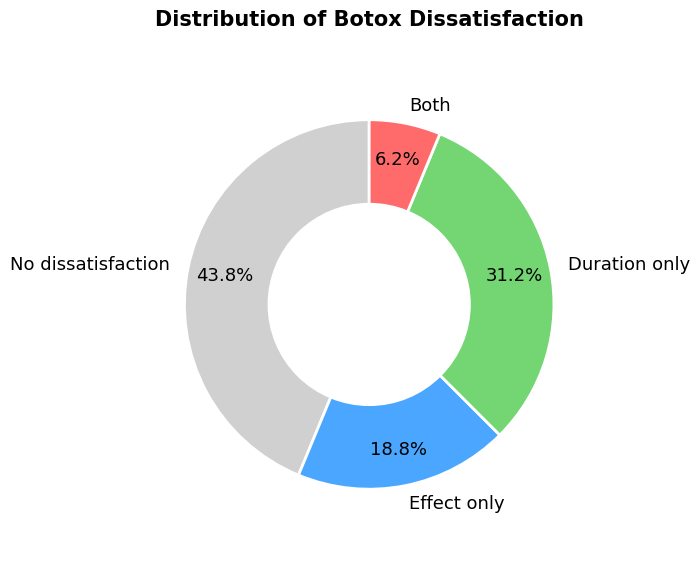

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 0. Load data & subset (always from source)
# =========================================
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')

# Type 1 = Blepharospasm
bleph = df[df['Type'] == 1].copy()

# =========================================
# 1. Preprocess Botox_dissatisfaction
# =========================================
bleph['Botox_dissatisfaction'] = (
    bleph['Botox_dissatisfaction']
    .astype(str)
    .str.strip()
    .replace({'nan': None})
)

# =========================================
# 2. Classification function (effect/duration/none)
# =========================================
def classify(text: str):
    # Patterns indicating "no dissatisfaction"
    if text in [None, '', '0', '0.0', '０', 'ちょうど', 'なし']:
        # Effect_related, Duration_related, No_dissatisfaction
        return 0, 0, 1

    # Duration-related words
    duration_pat = re.compile(
        r'\d+\s*(ヶ月?|週|M)|持たない|直前|ぐらい|切れる',
        re.I
    )
    # Effect-related words
    effect_pat = re.compile(
        r'効果|効|不満|調子|開けにく|まぶしく|効いていない',
        re.I
    )

    dur = bool(duration_pat.search(text))
    eff = bool(effect_pat.search(text))
    none = 0 if (dur or eff) else 1

    return int(eff), int(dur), int(none)

# =========================================
# 3. Create flags (Effect_related, Duration_related, No_dissatisfaction)
#    ※毎回ここで作り直すので、再実行しても安全
# =========================================
bleph[['Effect_related',
       'Duration_related',
       'No_dissatisfaction']] = (
    bleph['Botox_dissatisfaction']
    .apply(lambda x: pd.Series(classify(x)))
)

# =========================================
# 4. Derived flags for category breakdown
# =========================================

# Effect only = Effect 1 & Duration 0
bleph['Effect_only_flag'] = (
    (bleph['Effect_related'] == 1) &
    (bleph['Duration_related'] == 0)
).astype(int)

# Duration only = Duration 1 & Effect 0
bleph['Duration_only_flag'] = (
    (bleph['Duration_related'] == 1) &
    (bleph['Effect_related'] == 0)
).astype(int)

# Both Effect & Duration
bleph['Both_flag'] = (
    (bleph['Effect_related'] == 1) &
    (bleph['Duration_related'] == 1)
).astype(int)

# No dissatisfaction
bleph['None_flag'] = bleph['No_dissatisfaction'].astype(int)

# =========================================
# 5. Count each category
# =========================================
n_total = len(bleph)

count_none     = bleph['None_flag'].sum()
count_effect   = bleph['Effect_only_flag'].sum()
count_duration = bleph['Duration_only_flag'].sum()
count_both     = bleph['Both_flag'].sum()

pct_none     = round(count_none / n_total * 100, 1)
pct_effect   = round(count_effect / n_total * 100, 1)
pct_duration = round(count_duration / n_total * 100, 1)
pct_both     = round(count_both / n_total * 100, 1)

# =========================================
# 6. Summary table (English)
# =========================================
summary_table = pd.DataFrame([
    ["No dissatisfaction", count_none,     pct_none],
    ["Effect only",        count_effect,   pct_effect],
    ["Duration only",      count_duration, pct_duration],
    ["Both",               count_both,     pct_both],
], columns=["Category", "Count", "Percent (%)"])

print("\n=== Dissatisfaction Summary (English) ===")
print(summary_table)

# =========================================
# 7. Pie chart (4 categories, English labels)
# =========================================
import matplotlib.pyplot as plt

# ==== Data (from your computed counts) ====
labels = ["No dissatisfaction", "Effect only", "Duration only", "Both"]
sizes = [count_none, count_effect, count_duration, count_both]

# ==== Modern flat colors ====
colors = ["#d0d0d0", "#4aa6ff", "#73d673", "#ff6b6b"]  # gray / blue / green / red

# ==== Plot ====
plt.figure(figsize=(7, 6))

# Outer pie
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.80,        # tighter inner text
    textprops={'color': 'black', 'fontsize': 13},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # clean borders
)

# Donut hole (create modern ring style)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

# Title
plt.title("Distribution of Botox Dissatisfaction", fontsize=15, weight='bold')

plt.axis('equal')
plt.tight_layout()
plt.show()



In [ ]:
# Google Drive (必要なら実行)
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import scipy.stats as stats
import re
import statsmodels.formula.api as smf

# -----------------------------
# 1. データ読み込み・前処理
# -----------------------------
file_path = '/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx'
df = pd.read_excel(file_path, sheet_name='Data')
df.columns = df.columns.str.strip()

# Type 1（Blepharospasm）のみ
bleph = df[df['Type'] == 1].copy()

# Sex / Surgery history
bleph['Sex_label'] = bleph['Sex'].map({0: 'Male', 1: 'Female'})
bleph['Sex_female'] = (bleph['Sex_label'] == 'Female').astype(int)

def has_surgery(val):
    if pd.isna(val): return 'No'
    if isinstance(val, (int, float)) and val == 0: return 'No'
    if isinstance(val, str) and re.fullmatch(r'\s*0\s*', val): return 'No'
    return 'Yes'
bleph['Surgery_history'] = bleph['History'].apply(has_surgery)
bleph['Surgery_history_yes'] = (bleph['Surgery_history'] == 'Yes').astype(int)

# Sensory trick 有無
bleph['Sensory_trick_present'] = (
    (bleph['SensoryTrick_temple'] == 1) |
    (bleph['SensoryTrick_subbrow'] == 1)
).astype(int)

# Botox_dissatisfaction 分類
bleph['Botox_dissatisfaction'] = (
    bleph['Botox_dissatisfaction'].astype(str).str.strip()
    .replace({'nan': None})
)

def classify(text):
    if text in [None, '', '0', '0.0', '０', 'ちょうど', 'なし']:
        return pd.Series({'Effect_related':0,'Duration_related':0,'No_dissatisfaction':1})
    dur_p = re.search(r'\d+\s*(?:ヶ月?|週|M)|持たない|直前|ぐらい|切れる', text, re.I)
    eff_p = re.search(r'効果|効|不満|調子|開けにく|まぶしく|効いていない', text, re.I)
    dur = int(bool(dur_p))
    eff = int(bool(eff_p))
    none = 0 if (dur or eff) else 1
    return pd.Series({'Effect_related':eff,'Duration_related':dur,'No_dissatisfaction':none})

bleph[['Effect_related','Duration_related','No_dissatisfaction']] = (
    bleph['Botox_dissatisfaction'].apply(classify)
)

# 非数値カテゴリを int に
for v in ['Botox_abovebrow', 'Botox_glabellar']:
    bleph[v] = bleph[v].astype(float).astype('Int64').fillna(0).astype(int)

# -----------------------------
# 2. 群間比較
# -----------------------------
num_vars = ['Age','Duration','Interval','Botox_unit']
cat_vars = ['Sex_female','Surgery_history_yes',
            'Botox_abovebrow','Botox_glabellar',
            'Effect_related','Duration_related','No_dissatisfaction']

results = []

# 数値
for var in num_vars:
    g1 = bleph.loc[bleph['Sensory_trick_present']==1, var].dropna()
    g0 = bleph.loc[bleph['Sensory_trick_present']==0, var].dropna()
    med1, med0 = g1.median(), g0.median()
    u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    results.append({'Variable':var,'Type':'Numeric',
                    'Median_with':med1,'Median_without':med0,
                    'Effect_size':med1-med0,'P_value':p})

# カテゴリ
for var in cat_vars:
    tab = pd.crosstab(bleph['Sensory_trick_present'], bleph[var])
    # 列不足回避
    for col in [0,1]:
        if col not in tab.columns: tab[col] = 0
    tab = tab[[0,1]]
    p = stats.fisher_exact(tab)[1] if (tab.values<5).any() else stats.chi2_contingency(tab)[1]
    or_ = ((tab.loc[1,1]*tab.loc[0,0]) / (tab.loc[1,0]*tab.loc[0,1]+1e-9))
    prop1 = tab.loc[1,1]/tab.loc[1].sum()
    prop0 = tab.loc[0,1]/tab.loc[0].sum()
    results.append({'Variable':var,'Type':'Categorical',
                    'Median_with':prop1,'Median_without':prop0,
                    'Effect_size':or_,'P_value':p})

summary_df = pd.DataFrame(results).round(4)
print('\n=== Group Comparison ===')
print(summary_df.to_string(index=False))

# -----------------------------
# 3. 単変量ロジスティック回帰
# -----------------------------
logit_rows = []
for var in num_vars + cat_vars:
    formula = f'Sensory_trick_present ~ {var}'
    try:
        model = smf.logit(formula, data=bleph).fit(disp=False)
        or_ = np.exp(model.params[1])
        ci_low, ci_high = np.exp(model.conf_int().loc[var])
        p = model.pvalues[1]
        logit_rows.append({'Variable':var,'OR':round(or_,2),
                           'CI_low':round(ci_low,2),'CI_high':round(ci_high,2),
                           'P_value':round(p,4)})
    except Exception as e:
        print(f'Skipped {var}: {e}')

logit_df = pd.DataFrame(logit_rows)
print('\n=== Univariate Logistic Regression ===')
print(logit_df.to_string(index=False))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Group Comparison ===
           Variable        Type  Median_with  Median_without  Effect_size  P_value
                Age     Numeric      69.0000         67.0000       2.0000   0.9050
           Duration     Numeric      96.0000        156.0000     -60.0000   0.2901
           Interval     Numeric       3.0000          3.0000       0.0000   0.4825
         Botox_unit     Numeric      40.0000         40.0000       0.0000   0.9518
         Sex_female Categorical       0.6190          0.9091       0.1625   0.1148
Surgery_history_yes Categorical       0.4762          0.1818       4.0909   0.1389
    Botox_abovebrow Categorical       0.7143          0.6364       1.4286   0.7026
    Botox_glabellar Categorical       0.6190          0.3636       2.8437   0.2662
     Effect_related Categorical       0.2857          0.1818       1.8000   0.6808
   Duration_rel

/tmp/ipython-input-2549681310.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  or_ = np.exp(model.params[1])
/tmp/ipython-input-2549681310.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = model.pvalues[1]
/tmp/ipython-input-2549681310.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  or_ = np.exp(model.params[1])
/tmp/ipython-input-2549681310.py:112: FutureWarning: Series.__getitem__ treating keys as positions is d

In [ ]:
# =========================================================
# 眼瞼痙攣：不満（期間or効果）× 知覚トリック有無 2×2 マトリックス
# 　▶︎ 集計結果（DataFrame）も表示
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1) 不満フラグ（Effect または Duration が 1 なら「不満あり」）
bleph['Dissatisfied'] = (
    (bleph['Effect_related'] == 1) |
    (bleph['Duration_related'] == 1)
).astype(int)

# 2) クロス集計（行：不満なし/あり，列：トリックなし/あり）
mat_counts = (
    pd.crosstab(bleph['Dissatisfied'],
                bleph['Sensory_trick_present'])
      .reindex(index=[0, 1], columns=[0, 1], fill_value=0)
)
mat_counts.index = ['Not dissatisfied', 'Dissatisfied']
mat_counts.columns = ['Trick (–)', 'Trick (+)']

# ----------------------------
# ▼ DataFrame をそのまま表示
# ----------------------------
print('\n=== Contingency Table ===')
print(mat_counts)          # Colab なら `display(mat_counts)` でも OK

# ----------------------------
# ▼ ヒートマップ（上で作成したもの）
# ----------------------------
cmap = mpl.colormaps['viridis']
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
im = ax.imshow(mat_counts.values, cmap=cmap)

ax.set_xticks([0, 1]); ax.set_xticklabels(mat_counts.columns, fontweight='semibold')
ax.set_yticks([0, 1]); ax.set_yticklabels(mat_counts.index, fontweight='semibold')

total = mat_counts.values.sum()
norm = mpl.colors.Normalize(vmin=mat_counts.values.min(),
                            vmax=mat_counts.values.max())
for i in range(mat_counts.shape[0]):
    for j in range(mat_counts.shape[1]):
        cnt = mat_counts.iat[i, j]
        pct = cnt / total * 100
        bg = cmap(norm(cnt))
        lum = 0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]
        ax.text(j, i, f'{cnt}\n({pct:.1f}%)',
                ha='center', va='center',
                color=('black' if lum > 0.55 else 'white'),
                fontweight='bold')

ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which='minor', color='w', linewidth=2)

ax.set_title('Dissatisfaction × Sensory Trick Matrix', pad=12, fontsize=12)
ax.set_xlabel('Sensory Trick', labelpad=8)
ax.set_ylabel('Botox dissatisfaction', labelpad=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Count', rotation=90)

plt.tight_layout()
plt.show()


【解析結果サマリー】

■ 対象症例数: 32 例（眼瞼痙攣）

■ 知覚トリックの内訳（Sensory Trick Categories）
----------------------------------------
  Both      :  14 例 ( 43.8%)
  Temple    :   6 例 ( 18.8%)
  Eyebrow   :   1 例 (  3.1%)
  None      :  11 例 ( 34.4%)
----------------------------------------
  → 有効群 (Effective):   21 例 (65.6%)
  → 無効群 (Ineffective): 11 例 (34.4%)

■ 有効群 vs 無効群の比較
Factor                    Effective            Ineffective          P-value   
----------------------------------------------------------------------
Age (median)              69.0                 67.0                 0.91      
Female (%)                13 (61.9%)           10 (90.9%)           0.11      
Duration (median)         96.0                 156.0                0.29      
Surgery History (%)       10 (47.6%)           2 (18.2%)            0.14      
BTX Dissatisfaction (%)   14 (66.7%)           6 (54.5%)            0.70      
----------------------------------------------------------------------

■ 統計的有意差の判定 (α = 0.05)
--

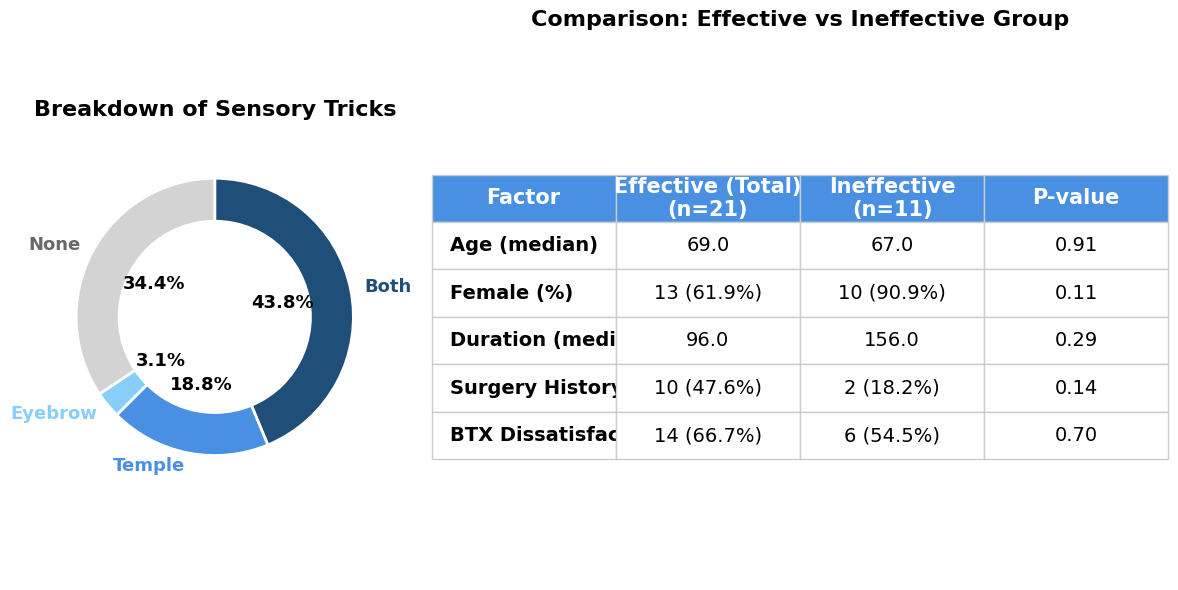

In [6]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import re

# ------------------------------
# 1. データ読み込みとリセット
# ------------------------------
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')
df.columns = df.columns.str.strip()
bleph = df[df['Type'] == 1].copy()

# ============================================================
# ★ここを追加: 不満フラグ (Effect_related) の再作成処理
# ============================================================
bleph['Botox_dissatisfaction'] = bleph['Botox_dissatisfaction'].astype(str).str.strip().replace({'nan': None})

def classify(text):
    if text in [None, '', '0', '0.0', '０', 'ちょうど', 'なし']:
        return 0, 0, 1
    duration_pat = re.compile(r'\d+\s*(ヶ月?|週|M)|持たない|直前|ぐらい|切れる', re.I)
    effect_pat = re.compile(r'効果|効|不満|調子|開けにく|まぶしく|効いていない', re.I)
    dur = bool(duration_pat.search(text))
    eff = bool(effect_pat.search(text))
    none = 0 if (dur or eff) else 1
    return int(eff), int(dur), int(none)

bleph[['Effect_related', 'Duration_related', 'No_dissatisfaction']] = (
    bleph['Botox_dissatisfaction'].apply(lambda x: pd.Series(classify(x)))
)

# ------------------------------
# 2. 知覚トリックの分類 (4分類)
# ------------------------------
def classify_trick(row):
    t = row['SensoryTrick_temple']
    s = row['SensoryTrick_subbrow']
    if t == 1 and s == 1:
        return 'Both'
    elif t == 1:
        return 'Temple'
    elif s == 1:
        return 'Eyebrow'
    else:
        return 'None'

bleph['Trick_Category'] = bleph.apply(classify_trick, axis=1)

category_order = ['Both', 'Temple', 'Eyebrow', 'None']
counts_pie = bleph['Trick_Category'].value_counts().reindex(category_order, fill_value=0)

# ------------------------------
# 3. 統計解析用フラグ (表用)
# ------------------------------
bleph['Sensory_trick_flag'] = (bleph['Trick_Category'] != 'None').astype(int)
bleph['Female_flag'] = (bleph['Sex'] == 1).astype(int)

def has_surgery(val):
    if pd.isna(val) or str(val).strip() in ['0', '0.0', 'nan']: return 0
    return 1
bleph['Surgery_flag'] = bleph['History'].apply(has_surgery)

def has_dissatisfaction(val):
    s = str(val).strip()
    if s in ['nan', '0', '0.0', 'なし', 'None', '']: return 0
    return 1
bleph['Dissatisfaction_flag'] = bleph['Botox_dissatisfaction'].apply(has_dissatisfaction)

# ------------------------------
# 4. 表データの作成 (有効 vs 無効)
# ------------------------------
group_eff = bleph[bleph['Sensory_trick_flag'] == 1]
group_ineff = bleph[bleph['Sensory_trick_flag'] == 0]

data_table = []

def analyze_numeric(label, col_name):
    med_eff = group_eff[col_name].median()
    med_ineff = group_ineff[col_name].median()
    stat, p = stats.mannwhitneyu(group_eff[col_name].dropna(), group_ineff[col_name].dropna())
    return [f"{label} (median)", f"{med_eff:.1f}", f"{med_ineff:.1f}", f"{p:.2f}"]

def analyze_categorical(label, col_name):
    n_eff, n_ineff = len(group_eff), len(group_ineff)
    cnt_eff = group_eff[col_name].sum()
    cnt_ineff = group_ineff[col_name].sum()
    odds, p = stats.fisher_exact([[cnt_eff, n_eff - cnt_eff], [cnt_ineff, n_ineff - cnt_ineff]])
    return [f"{label} (%)", f"{cnt_eff} ({(cnt_eff/n_eff)*100:.1f}%)", f"{cnt_ineff} ({(cnt_ineff/n_ineff)*100:.1f}%)", f"{p:.2f}"]

data_table.append(analyze_numeric("Age", "Age"))
data_table.append(analyze_categorical("Female", "Female_flag"))
data_table.append(analyze_numeric("Duration", "Duration"))
data_table.append(analyze_categorical("Surgery History", "Surgery_flag"))
data_table.append(analyze_categorical("BTX Dissatisfaction", "Dissatisfaction_flag"))

columns_table = ["Factor", f"Effective (Total)\n(n={len(group_eff)})", f"Ineffective\n(n={len(group_ineff)})", "P-value"]

# ==============================================================
# ★ 結果のテキスト出力
# ==============================================================
print("=" * 70)
print("【解析結果サマリー】")
print("=" * 70)

# 全体のサンプルサイズ
total_n = len(bleph)
print(f"\n■ 対象症例数: {total_n} 例（眼瞼痙攣）\n")

# 知覚トリックの内訳
print("■ 知覚トリックの内訳（Sensory Trick Categories）")
print("-" * 40)
for cat in category_order:
    n = counts_pie[cat]
    pct = (n / total_n) * 100
    print(f"  {cat:10s}: {n:3d} 例 ({pct:5.1f}%)")

effective_n = len(group_eff)
ineffective_n = len(group_ineff)
effective_pct = (effective_n / total_n) * 100
print("-" * 40)
print(f"  → 有効群 (Effective):   {effective_n} 例 ({effective_pct:.1f}%)")
print(f"  → 無効群 (Ineffective): {ineffective_n} 例 ({100-effective_pct:.1f}%)")

# 比較表の結果
print("\n" + "=" * 70)
print("■ 有効群 vs 無効群の比較")
print("=" * 70)
print(f"{'Factor':<25} {'Effective':<20} {'Ineffective':<20} {'P-value':<10}")
print("-" * 70)
for row in data_table:
    print(f"{row[0]:<25} {row[1]:<20} {row[2]:<20} {row[3]:<10}")
print("-" * 70)

# 統計的有意差の判定
print("\n■ 統計的有意差の判定 (α = 0.05)")
print("-" * 40)
for row in data_table:
    factor = row[0]
    p_val = float(row[3])
    if p_val < 0.05:
        sig = "★ 有意差あり"
    else:
        sig = "  有意差なし"
    print(f"  {factor:<25}: P = {p_val:.2f} {sig}")

print("\n" + "=" * 70)
print("【解析完了】")
print("=" * 70)

# ------------------------------
# 5. 描画
# ------------------------------
fig = plt.figure(figsize=(12, 6))

# --- A. 左側：4分類の円グラフ ---
ax1 = fig.add_subplot(1, 3, 1)

colors_map = {
    'Both': '#1F4E79',
    'Temple': '#4A90E2',
    'Eyebrow': '#87CEFA',
    'None': '#D3D3D3'
}
colors = [colors_map[cat] for cat in counts_pie.index]

wedges, texts, autotexts = ax1.pie(
    counts_pie,
    labels=counts_pie.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    counterclock=False,
    textprops={'fontsize': 13, 'weight': 'bold'},
    pctdistance=0.5,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
ax1.add_artist(centre_circle)
ax1.set_title("Breakdown of Sensory Tricks", fontsize=16, weight='bold', pad=20)

for t, cat in zip(texts, counts_pie.index):
    if cat == 'None':
        t.set_color('dimgray')
    else:
        t.set_color(colors_map[cat])

for t in autotexts:
    t.set_color('black')

# --- B. 右側：比較表 ---
ax2 = fig.add_subplot(1, 3, (2, 3))
ax2.axis('off')

table = ax2.table(
    cellText=data_table,
    colLabels=columns_table,
    loc='center',
    cellLoc='center',
    colColours=['#EEEEEE']*4
)

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if row == 0:
        cell.set_text_props(weight='bold', fontsize=15)
        cell.set_facecolor('#4A90E2')
        cell.set_text_props(color='white')
    else:
        if col == 0:
            cell.set_text_props(weight='bold', ha='left')
            cell.set_text_props(position=(0.1, 0.5))

ax2.set_title("Comparison: Effective vs Ineffective Group", fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import re

# =========================================================
# 1. データ読み込みと前処理
# =========================================================
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')
df.columns = df.columns.str.strip()

# 対象：Type 1 = Blepharospasm
bleph = df[df['Type'] == 1].copy()
n_total = len(bleph)

# =========================================================
# 2. Clutch_glasses 使用歴の集計
# =========================================================
glasses_map = {0:'No', 1:'Yes', 2:'Unknown'}
bleph['Clutch_glasses_cat'] = bleph['Clutch_glasses'].map(glasses_map)

glasses_df = (
    bleph['Clutch_glasses_cat']
    .value_counts(dropna=False)
    .reindex(['No','Yes','Unknown'])
    .rename_axis('Clutch_glasses')
    .to_frame('Count')
)
glasses_df['Percent'] = (glasses_df['Count']/n_total*100).round(1)

print('\n=== Clutch glasses usage ===')
print(glasses_df)

# =========================================================
# 3. 不満フラグの作成 (統計用)
# =========================================================
# まず文字列としてクリーニング
bleph['Clutch_diss_clean'] = (
    bleph['Clutch_dissatisfaction']
        .astype(str).str.strip()
        .replace({'nan': None, 'None': None})
)

def is_no_dissatisfaction(txt):
    """空白・0・なし などは不満なし (0)。それ以外を不満あり (1)。"""
    if txt in [None, '', '0', '0.0', '０', 'なし']:
        return 0
    return 1

bleph['Has_clutch_diss'] = bleph['Clutch_diss_clean'].apply(is_no_dissatisfaction)

diss_df = (
    bleph['Has_clutch_diss']
    .value_counts(dropna=False)
    .rename({0:'No dissatisfaction', 1:'Has dissatisfaction'})
    .rename_axis('Clutch_dissatisfaction_flag')
    .to_frame('Count')
)
diss_df['Percent'] = (diss_df['Count']/n_total*100).round(1)

print('\n=== Clutch glasses dissatisfaction flag (Quantitative) ===')
print(diss_df)

# =========================================================
# 4. 使用歴 × 不満フラグ 交差表 + χ² 検定
# =========================================================
cross_tab = pd.crosstab(bleph['Clutch_glasses_cat'], bleph['Has_clutch_diss'])
cross_tab.columns = ['No_dissatisfaction', 'Has_dissatisfaction']
print('\n=== Crosstab: Usage × Dissatisfaction ===')
print(cross_tab)

# χ²（Unknown を含めた 3×2 表）
chi2, p, dof, ex = stats.chi2_contingency(cross_tab)
print(f'\nChi-square : χ² = {chi2:.2f}, df = {dof}, p = {p:.4f}')

# =========================================================
# 5. 【追加】全コメント抽出リスト（手動仕分け用）
# =========================================================
# 表示設定：長い文章も省略せずに表示する
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# 分類しやすいようにラベル付け
# 0=No (現在なし/中止), 1=Yes (現在使用中), 2=Unknown
status_label_map = {0: 'No (中止/なし)', 1: 'Yes (使用中)', 2: 'Unknown'}
bleph['Current_Status'] = bleph['Clutch_glasses'].map(status_label_map)

# 意味のあるコメントだけを抽出するフィルタ
# (すでに作成した 'Clutch_diss_clean' を利用)
comments_df = bleph.loc[bleph['Has_clutch_diss'] == 1, ['Current_Status', 'Clutch_diss_clean']].copy()

# 見やすく並べ替え（Statusごと）
comments_df = comments_df.sort_values(by='Current_Status')

print('\n' + '='*70)
print(f'  ★ Qualitative Analysis: Full Comment List (n={len(comments_df)})')
print('  ※ このリストを見て「不満による中止」か「不満あり継続」か分類してください')
print('='*70)
print(comments_df)


=== Clutch glasses usage ===
                Count  Percent
Clutch_glasses                
No                  9     28.1
Yes                10     31.2
Unknown            13     40.6

=== Clutch glasses dissatisfaction flag (Quantitative) ===
                             Count  Percent
Clutch_dissatisfaction_flag                
No dissatisfaction              18     56.2
Has dissatisfaction             14     43.8

=== Crosstab: Usage × Dissatisfaction ===
                    No_dissatisfaction  Has_dissatisfaction
Clutch_glasses_cat                                         
No                                   7                    2
Unknown                             11                    2
Yes                                  0                   10

Chi-square : χ² = 18.80, df = 2, p = 0.0001

  ★ Qualitative Analysis: Full Comment List (n=14)
  ※ このリストを見て「不満による中止」か「不満あり継続」か分類してください
   Current_Status  \
12     No (中止/なし)   
50     No (中止/なし)   
27        Unknown   
33        Unkno

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1. データ読み込み
# ------------------------------
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')
bleph = df[df['Type'] == 1].copy()

# ------------------------------
# 2. データ集計 (使用歴)
# ------------------------------
# 値の定義: 1=Yes(あり), 0=No(なし), 2=Unknown(不明)
# 集計して、表示したい順序 (Yes -> No -> Unknown) に並べ替え
counts = bleph['Clutch_glasses'].value_counts()
desired_order = [1, 0, 2] # 1:Yes, 0:No, 2:Unknown
ordered_counts = [counts.get(k, 0) for k in desired_order]
ordered_labels = ['Yes', 'No', 'Unknown']

# ------------------------------
# 3. グラフ描画
# ------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# 配色設定
# Yes: 青 (#4A90E2)
# No: 濃いグレー (#A9A9A9) - 明確に区別するため少し濃いめ
# Unknown: 薄いグレー (#E0E0E0) - 目立たないように
colors = ['#4A90E2', '#A9A9A9', '#E0E0E0']

wedges, texts, autotexts = ax.pie(
    ordered_counts,
    labels=ordered_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    counterclock=False,
    pctdistance=0.5, # 数字を中心寄りに
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, # 境界線
    textprops={'fontsize': 32, 'weight': 'bold'} # ラベル文字設定
)

# --- デザイン調整 ---

# 真ん中を白く抜いてドーナツ型にする
centre_circle = plt.Circle((0,0), 0.60, fc='white')
ax.add_artist(centre_circle)

# タイトル
ax.set_title("History of Clutch Glasses Usage", fontsize=20, weight='bold', pad=20)

# テキストの色調整
# ラベル(Yes/No...)の色をグラフの色に合わせる
for t, color in zip(texts, colors):
    t.set_color(color)
    t.set_fontsize(18) # ラベルは少し大きく

# パーセンテージの色を黒にする
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(20)

# 中心に合計人数を表示
ax.text(0, 0, f'Total\nn={sum(ordered_counts)}', ha='center', va='center', fontsize=36, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 0. 前準備：データ読み込み & 必須列の整形
# =========================================================
import pandas as pd, numpy as np, scipy.stats as stats, statsmodels.formula.api as smf

file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')
df.columns = df.columns.str.strip()

# ---------- 眼瞼痙攣 (Type==1) ----------
bleph = df[df['Type'] == 1].copy()

# ---------- Clutch_glasses 0=No, 1=Yes, 2=Unknown ----------
bleph = bleph[bleph['Clutch_glasses'].isin([0,1])]   # Unknown(2) を除外
bleph['Use_clutch'] = (bleph['Clutch_glasses'] == 1).astype(int)  # 1=使用者

# ---------- Sensory trick 有無 ----------
bleph['Sensory_trick'] = (
    (bleph['SensoryTrick_temple'] == 1) |
    (bleph['SensoryTrick_subbrow'] == 1)
).astype(int)

# ---------- Sex ダミー (Female=1) ----------
bleph['Female'] = (bleph['Sex'] == 1).astype(int)

# ---------- 他の候補変数 ----------
num_vars = ['Age', 'Duration', 'Interval', 'Botox_unit']
cat_vars = ['Female', 'Sensory_trick', 'Botox_abovebrow', 'Botox_glabellar']

# =========================================================
# 1. 記述統計：使用者 vs 非使用者
# =========================================================
desc_rows = []
for var in num_vars:
    for grp, data in bleph.groupby('Use_clutch'):
        s = data[var].describe()
        desc_rows.append({
            'Variable': var,
            'Group': 'Yes' if grp==1 else 'No',
            'n': int(s['count']),
            'Median': round(s['50%'],1),
            'IQR': round(s['75%']-s['25%'],1)
        })
desc_df = pd.DataFrame(desc_rows)

cross_rows = []
for var in cat_vars:
    ct = pd.crosstab(bleph['Use_clutch'], bleph[var])
    # 組み合わせ (使用者=1 の割合)
    prop_yes = ct.loc[1,1] / ct.loc[1].sum() if 1 in ct.loc[1] else np.nan
    prop_no  = ct.loc[0,1] / ct.loc[0].sum() if 1 in ct.loc[0] else np.nan
    p = stats.fisher_exact(ct)[1] if (ct.values<5).any() else stats.chi2_contingency(ct)[1]
    cross_rows.append({
        'Variable': var,
        'Yes(%)': round(prop_yes*100,1),
        'No(%)':  round(prop_no*100,1),
        'p': round(p,4)
    })
cross_df = pd.DataFrame(cross_rows)

print("\n=== Numeric Summary (Median [IQR]) ===")
print(desc_df.pivot(index='Variable', columns='Group', values=['Median','IQR']))

print("\n=== Categorical Comparison (Yes vs No) ===")
print(cross_df.set_index('Variable'))

# =========================================================
# 2. 単変量ロジスティック回帰（目的：Use_clutch）
# =========================================================
uni_rows = []
for v in num_vars + cat_vars:
    model = smf.logit(f'Use_clutch ~ {v}', data=bleph).fit(disp=False)
    OR   = np.exp(model.params[1])
    CIlo, CIhi = np.exp(model.conf_int().loc[v])
    uni_rows.append({'Variable': v,
                     'OR': round(OR,2),
                     '95%CI_low': round(CIlo,2),
                     '95%CI_high': round(CIhi,2),
                     'p': round(model.pvalues[1],4)})
uni_df = pd.DataFrame(uni_rows)

print("\n=== Univariate Logistic Regression ===")
print(uni_df.set_index('Variable'))

# =========================================================
# 3. 多変量ロジスティック回帰
#    - Sensory_trick と臨床的に重要そうな Age, Sex を例示
# =========================================================
multiv_model = smf.logit('Use_clutch ~ Sensory_trick + Age + Female', data=bleph).fit()
print("\n=== Multivariable Model Summary ===")
print(multiv_model.summary())

# オッズ比 & 95%CI 表（読みやすい形）
params = multiv_model.params; conf = multiv_model.conf_int()
or_table = pd.DataFrame({
    'OR': np.exp(params),
    'CI_low': np.exp(conf[0]),
    'CI_high': np.exp(conf[1]),
    'p': multiv_model.pvalues
}).round(3)
print("\n=== Multivariable OR ===")
print(or_table)



=== Numeric Summary (Median [IQR]) ===
           Median          IQR      
Group          No    Yes    No   Yes
Variable                            
Age          74.0   70.0   9.0   9.0
Botox_unit   40.0   40.0   5.0  17.5
Duration     50.0  130.0  51.0  57.0
Interval      3.0    3.0   1.0   0.0

=== Categorical Comparison (Yes vs No) ===
                 Yes(%)  No(%)       p
Variable                              
Female             50.0   77.8  0.3498
Sensory_trick     100.0   55.6  0.0325
Botox_abovebrow    60.0   88.9  0.3034
Botox_glabellar    60.0   55.6  1.0000

=== Univariate Logistic Regression ===
                           OR  95%CI_low  95%CI_high       p
Variable                                                    
Age              9.700000e-01       0.89        1.07  0.5801
Duration         1.040000e+00       1.00        1.07  0.0233
Interval         1.050000e+00       0.48        2.32  0.8993
Botox_unit       9.600000e-01       0.86        1.07  0.4465
Female           

/tmp/ipython-input-231820069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  OR   = np.exp(model.params[1])
/tmp/ipython-input-231820069.py:79: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'p': round(model.pvalues[1],4)})
/tmp/ipython-input-231820069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  OR   = np.exp(model.params[1])
/tmp/ipython-input-231820069.py:79: FutureWarning: Series.__getitem__ treating keys as position

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# =========================================================
# 1. データ読み込みとフラグ作成
# =========================================================
file_path = "/content/drive/MyDrive/発表/2025神経眼科学会/知覚トリックの頻度調査.xlsx"
df = pd.read_excel(file_path, sheet_name='Data')
df.columns = df.columns.str.strip()
bleph = df[df['Type'] == 1].copy()
n_total = len(bleph)

# 知覚トリックフラグ
bleph['Sensory_trick_flag'] = (
    (bleph['SensoryTrick_temple'] == 1) |
    (bleph['SensoryTrick_subbrow'] == 1)
).astype(int)

# クラッチ使用有無フラグ
bleph['Clutch_use'] = (bleph['Clutch_glasses'] == 1).astype(int)

# =========================================================
# 2. カウント
# =========================================================
group_trick_pos = bleph[bleph['Sensory_trick_flag'] == 1]
group_trick_neg = bleph[bleph['Sensory_trick_flag'] == 0]

count_exp_diss = bleph[(bleph['Clutch_use'] == 1) & (bleph['Clutch_satisfaction'] == 0)].shape[0]
count_exp_sat = bleph[(bleph['Clutch_use'] == 1) & (bleph['Clutch_satisfaction'] == 1)].shape[0]
count_trick_neg = len(group_trick_neg)
count_no_exp = len(group_trick_pos) - (count_exp_diss + count_exp_sat)

# 順序: No Effect → Dissatisfied → No Experience → Satisfied
counts = np.array([
    count_trick_neg,    # 1. No Effect
    count_exp_diss,     # 2. Dissatisfied
    count_no_exp,       # 3. No Experience
    count_exp_sat       # 4. Satisfied
])
percentages = np.round((counts / n_total) * 100, 1)

# =========================================================
# 3. グラフ描画（外部ラベル対応版）
# =========================================================
category_labels = [
    "1. Trick (–) / No Effect",
    "2. Trick (+) / Experienced & Dissatisfied",
    "3. Trick (+) / No Experience",
    "4. Trick (+) / Experienced & Satisfied",
]

# 色覚に配慮したカラーパレット（赤と緑を離す）
colors = ['#9E9E9E',    # ダークグレー (No Effect)
          '#EF5350',    # レッド (Dissatisfied)
          '#64B5F6',    # ブルー (No Experience)
          '#66BB6A']    # グリーン (Satisfied)

fig, ax = plt.subplots(figsize=(12, 5))

labels = [f"Total Cohort\n(N={n_total})"]
left = np.zeros(len(labels))

# 棒グラフを積み上げる
bars = []
for i, count in enumerate(counts):
    p = ax.barh(labels, count, left=left, label=category_labels[i],
                color=colors[i], edgecolor='white', linewidth=2)
    bars.append((left[0], count, percentages[i], colors[i], category_labels[i]))
    left += count

# データラベルの配置（小さいセグメントは外部ラベル）
for i, (start, count, pct, color, label) in enumerate(bars):
    if count > 0:
        mid_pos = start + count / 2

        # 5%未満は外部ラベルを使用
        if pct < 5.0:
            ax.annotate(
                f'{count}\n({pct:.1f}%)',
                xy=(start + count, 0),
                xytext=(10, 0),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                ha='left',
                va='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color,
                         edgecolor='white', linewidth=2, alpha=0.9),
                color='white',
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0',
                              color='gray', lw=1.5)
            )
        else:
            # 内側にラベルを配置
            ax.text(mid_pos, 0,
                    f'{count}\n({pct:.1f}%)',
                    ha='center', va='center',
                    color='white',
                    fontsize=20,
                    fontweight='bold')

# デザイン調整
ax.set_xlim(-2, n_total + 5)
ax.set_ylim(-0.8, 0.8)
ax.set_xticks([])
ax.set_yticks([])

# タイトル
ax.text(0, 1.2, 'Distribution by Sensory Trick & Clutch Glasses Status',
        fontsize=16, weight='bold', transform=ax.transData,
        va='bottom')

# 枠線を非表示
for spine in ax.spines.values():
    spine.set_visible(False)

# 凡例
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
                   ncol=2, fontsize=11, frameon=True,
                   fancybox=True, shadow=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/colorblind_friendly_graph.png', dpi=300,
#             bbox_inches='tight', facecolor='white')
plt.show()

print(f"✓ 赤と緑を離した色覚配慮版を作成しました (N={n_total})")
print("✓ 小さいセグメントは外部ラベルで表示")